# фильтрация артефактов ЭМГ

## зависимости

Первая ячейка устанавливает `EMD-signal` именно в активное Python-окружение Jupyter. После первой установки перезапустите kernel и выполните notebook заново.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("PyEMD") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "EMD-signal"
    ])
    print("EMD-signal installed. Restart the kernel, then run all cells.")
else:
    print("EMD-signal is available in:", sys.executable)

EMD-signal is available in: /Library/Developer/CommandLineTools/usr/bin/python3


## импорты

In [2]:
from pathlib import Path

from IPython.display import display
from PyEMD import EMD
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy import linalg, signal

mne.set_log_level("WARNING")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True


## пути

In [3]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_raw_dir = project_root / "data" / "raw"
data_interim_dir = project_root / "data" / "interim"
data_processed_dir = project_root / "data" / "processed"
qc_dir = project_root / "outputs" / "qc"
tables_dir = project_root / "outputs" / "tables"

for folder in [data_interim_dir, data_processed_dir, qc_dir, tables_dir]:
    folder.mkdir(parents=True, exist_ok=True)

fif_path = data_raw_dir / "raw_artifacts_emg.fif"

# пути для ручного запуска
# fif_path = Path(r"/Users/user/Desktop/raw_artifacts_emg.fif")
# fif_path = Path(r"C:\\Users\\user\\Desktop\\raw_artifacts_emg.fif")

recording_name = (
    fif_path.name
    .removesuffix(".fif.gz")
    .removesuffix(".fif")
)
annotations_path = qc_dir / f"{recording_name}-annot.fif"
legacy_annotations_path = qc_dir / f"{recording_name}_annotations.csv"

print("Project root:", project_root)
print("Input FIF:", fif_path)
print("Annotations:", annotations_path)
print("Interim:", data_interim_dir)
print("Processed:", data_processed_dir)
print("QC:", qc_dir)
print("Tables:", tables_dir)


Project root: /Users/sofiaefimochkina/Documents/emg_artifacts_filter
Input FIF: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/raw/raw_artifacts_emg.fif
Annotations: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif
Interim: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim
Processed: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed
QC: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc
Tables: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/tables


## загрузка данных

In [4]:
if not fif_path.exists():
    raise FileNotFoundError(f"Файл не найден: {fif_path}")

raw_base = mne.io.read_raw_fif(fif_path, preload=True)
raw_base.set_channel_types({
    channel: "emg" for channel in raw_base.ch_names
})

# параметры влияют только на отображение, данные остаются в вольтах
emg_browser_kwargs = dict(
    duration=1.0,
    n_channels=8,
    scalings={"emg": 4e-3},
)

# восстанавливаем сохранённую разметку при повторном запуске
if annotations_path.exists():
    saved_annotations = mne.read_annotations(annotations_path)
    raw_base.set_annotations(saved_annotations)
    annotations_source = annotations_path
elif legacy_annotations_path.exists():
    # преобразуем onset старого CSV из времени Unix в секунды записи
    annotations_table = pd.read_csv(legacy_annotations_path)
    epoch = pd.Timestamp("1970-01-01", tz="UTC")
    annotation_onsets = (
        pd.to_datetime(annotations_table["onset"], utc=True) - epoch
    ).dt.total_seconds().to_numpy()
    saved_annotations = mne.Annotations(
        onset=annotation_onsets,
        duration=annotations_table["duration"].to_numpy(),
        description=annotations_table["description"].astype(str).to_numpy(),
        orig_time=None,
    )
    raw_base.set_annotations(saved_annotations)
    annotations_source = legacy_annotations_path
else:
    annotations_source = None

sfreq = raw_base.info["sfreq"]
duration_s = raw_base.n_times / sfreq

print("File:", fif_path.name)
print("Channels:", len(raw_base.ch_names))
print("sfreq:", sfreq)
print("Duration, s:", round(duration_s, 2))
print("First channels:", raw_base.ch_names[:10])
print("Annotations:", len(raw_base.annotations))
print("Annotations loaded from:", annotations_source or "input FIF")


File: raw_artifacts_emg.fif
Channels: 8
sfreq: 4000.0
Duration, s: 117.52
First channels: ['RF R', 'BF R', 'TA R', 'GM R', 'RF L', 'BF L', 'TA L', 'GM L']
Annotations: 34
Annotations loaded from: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif


/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_92397/3493622666.py:4: RuntimeWarning: This filename (/Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/raw/raw_artifacts_emg.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_base = mne.io.read_raw_fif(fif_path, preload=True)


## проверка записи

In [5]:
if "TA L" not in raw_base.info["bads"]:
    raw_base.info["bads"].append("TA L")

channels_table = pd.DataFrame(
    {
        "channel": raw_base.ch_names,
        "type": raw_base.get_channel_types(),
        "bad": [ch in raw_base.info["bads"] for ch in raw_base.ch_names],
    }
)

display(channels_table)
print(f"Sampling rate: {raw_base.info['sfreq']} Hz")
print(f"Duration: {duration_s:.2f} s")
print("Bad channels:", raw_base.info["bads"] or "none")

raw_base.plot(**emg_browser_kwargs)


,channel,type,bad
0,RF R,emg,False
1,BF R,emg,False
2,TA R,emg,False
3,GM R,emg,False
4,RF L,emg,False
5,BF L,emg,False
6,TA L,emg,True
7,GM L,emg,False


Sampling rate: 4000.0 Hz
Duration: 117.53 s
Bad channels: ['TA L']


## сохранение аннотаций (опционально, фильтрация их не использует)

In [6]:

raw_base.annotations.save(
    annotations_path,
    overwrite=True,
)

print(f"Сохранено аннотаций: {len(raw_base.annotations)}")
print("Файл:", annotations_path)

Сохранено аннотаций: 34
Файл: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/outputs/qc/raw_artifacts_emg-annot.fif


## выбор каналов

In [7]:
emg_channels = ["GM R", "GM L", "RF R", "RF L", "TA R", "TA L", "BF R", "BF L"]
right_channels = ["GM R", "RF R", "TA R", "BF R"]
left_channels = ["GM L", "RF L", "TA L", "BF L"]

excluded_channels = ["TA L"]

print("EMG channels:", emg_channels)
print("Right:", right_channels)
print("Left:", left_channels)
print("Excluded:", excluded_channels)


EMG channels: ['GM R', 'GM L', 'RF R', 'RF L', 'TA R', 'TA L', 'BF R', 'BF L']
Right: ['GM R', 'RF R', 'TA R', 'BF R']
Left: ['GM L', 'RF L', 'TA L', 'BF L']
Excluded: ['TA L']


## notch-фильтр 50 Гц

Это общая основа для всех последующих методов. Исходная запись далее используется только для сравнения.


In [8]:
analysis_channels = [
    channel for channel in emg_channels
    if channel not in excluded_channels
]
missing_channels = [
    channel for channel in analysis_channels
    if channel not in raw_base.ch_names
]
if missing_channels:
    raise ValueError(f"В записи отсутствуют каналы: {missing_channels}")

LINE_FREQ_HZ = 50.0
LINE_NOTCH_Q = 30.0
notch_b, notch_a = signal.iirnotch(
    LINE_FREQ_HZ, LINE_NOTCH_Q, fs=sfreq,
)
notched_emg_data = signal.filtfilt(
    notch_b, notch_a, raw_base.get_data(picks=analysis_channels), axis=1,
)
raw_notch = raw_base.copy().load_data()
notch_indices = [raw_notch.ch_names.index(ch) for ch in analysis_channels]
raw_notch._data[notch_indices] = notched_emg_data

assert np.array_equal(
    raw_notch.get_data(picks=excluded_channels),
    raw_base.get_data(picks=excluded_channels),
)
print("Notch frequency, Hz:", LINE_FREQ_HZ)
print("Notch Q:", LINE_NOTCH_Q)


Notch frequency, Hz: 50.0
Notch Q: 30.0


## CAR глобальный после notch

Глобальный CAR является отдельной ветвью и применяется непосредственно к `raw_notch`.


In [9]:
raw_car_global = raw_notch.copy().load_data()
reference_signal = raw_notch.get_data(picks=analysis_channels).mean(axis=0)
car_indices = [raw_car_global.ch_names.index(ch) for ch in analysis_channels]
raw_car_global._data[car_indices] -= reference_signal


## CAR по сторонам после notch

Левый/правый CAR — альтернативная ветвь от `raw_notch`, а не продолжение глобального CAR.


In [10]:
raw_car_left_right = raw_notch.copy().load_data()
for side_channels in [right_channels, left_channels]:
    side_car_channels = [
        channel for channel in side_channels
        if channel not in excluded_channels
    ]
    reference_signal = raw_notch.get_data(
        picks=side_car_channels
    ).mean(axis=0)
    side_indices = [
        raw_car_left_right.ch_names.index(ch)
        for ch in side_car_channels
    ]
    raw_car_left_right._data[side_indices] -= reference_signal


## Медленная часть notch-фильтрованной записи

SVD и GED используют то же разделение на медленный артефакт и сохранённую быструю ЭМГ, что и раньше.


In [11]:
ARTIFACT_CUTOFF_HZ = 30.0
lowpass_filter = signal.butter(
    4, ARTIFACT_CUTOFF_HZ, btype="lowpass", fs=sfreq, output="sos",
)
slow_artifact_data = signal.sosfiltfilt(
    lowpass_filter, notched_emg_data, axis=1,
)
retained_emg_data = notched_emg_data - slow_artifact_data
assert np.allclose(
    slow_artifact_data + retained_emg_data,
    notched_emg_data,
)


## SVD rank-1 после notch

In [12]:
svd_covariance = np.cov(slow_artifact_data)
left_vectors, svd_singular_values, _ = np.linalg.svd(
    svd_covariance, full_matrices=False,
)
artifact_direction = left_vectors[:, :1]
svd_projector = (
    np.eye(len(analysis_channels))
    - artifact_direction @ artifact_direction.T
)
svd_artifact_model = artifact_direction @ (
    artifact_direction.T @ slow_artifact_data
)
svd_clean_data = notched_emg_data - svd_artifact_model
raw_svd = raw_notch.copy().load_data()
svd_indices = [raw_svd.ch_names.index(ch) for ch in analysis_channels]
raw_svd._data[svd_indices] = svd_clean_data

assert np.allclose(svd_projector, svd_projector.T)
assert np.allclose(svd_projector @ svd_projector, svd_projector)
assert np.isfinite(svd_clean_data).all()
print(
    "First SVD covariance fraction:",
    round(svd_singular_values[0] / svd_singular_values.sum(), 4),
)


First SVD covariance fraction: 0.4307


## GED медленных компонентов после notch

Параметры и логика GED не изменены; изменён только вход с raw на notch-фильтрованную запись.


In [13]:
GED_REGULARIZATION = 0.05
GED_MIN_POWER_RATIO = 3.0

def covariance(data):
    centered = data - data.mean(axis=1, keepdims=True)
    return centered @ centered.T / (centered.shape[1] - 1)

artifact_covariance = covariance(slow_artifact_data)
normal_covariance = covariance(retained_emg_data)
regularization = (
    GED_REGULARIZATION
    * np.trace(normal_covariance)
    / len(analysis_channels)
)
regularized_normal_covariance = (
    normal_covariance
    + regularization * np.eye(len(analysis_channels))
)
power_ratios, spatial_filters = linalg.eigh(
    artifact_covariance, regularized_normal_covariance,
)
selected_components = power_ratios > GED_MIN_POWER_RATIO
if not selected_components.any():
    raise ValueError("GED не нашёл компонент, специфичных для артефакта")

ged_filters = spatial_filters[:, selected_components]
component_signals = ged_filters.T @ slow_artifact_data
spatial_patterns = (
    slow_artifact_data
    @ component_signals.T
    @ np.linalg.pinv(component_signals @ component_signals.T)
)
ged_artifact_model = spatial_patterns @ component_signals
ged_clean_data = notched_emg_data - ged_artifact_model
raw_ged = raw_notch.copy().load_data()
ged_indices = [raw_ged.ch_names.index(ch) for ch in analysis_channels]
raw_ged._data[ged_indices] = ged_clean_data

display(pd.DataFrame({
    "slow artifact / retained EMG power": power_ratios[::-1],
    "remove": selected_components[::-1],
}))
assert np.isfinite(ged_clean_data).all()


/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_92397/3386255381.py:31: RuntimeWarning: divide by zero encountered in matmul
  @ np.linalg.pinv(component_signals @ component_signals.T)
/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_92397/3386255381.py:31: RuntimeWarning: overflow encountered in matmul
  @ np.linalg.pinv(component_signals @ component_signals.T)
/var/folders/4f/nvx50d4x7h5362c46mct3m3c0000gn/T/ipykernel_92397/3386255381.py:31: RuntimeWarning: invalid value encountered in matmul
  @ np.linalg.pinv(component_signals @ component_signals.T)


,slow artifact / retained EMG power,remove
0,10.377023,True
1,1.358582,False
2,0.564606,False
3,0.389895,False
4,0.209582,False
5,0.136086,False
6,0.055417,False


## EMD всех надёжных каналов после фильтров GED и notch

EMD is fitted at 250 Hz. Fast high-frequency artifact structure above the downsampled Nyquist frequency is not available to this EMD model.


,channel,component,imf,"median frequency, Hz",remove,artifact-specific candidate
0,GM R,IMF 1,1,60.607910,False,True
1,GM R,IMF 2,2,28.991699,False,True
2,GM R,IMF 3,3,23.437500,False,False
3,GM R,IMF 4,4,12.268066,True,True
4,GM R,IMF 5,5,7.446289,False,True
...,...,...,...,...,...,...
88,BF L,IMF 9,9,0.488281,False,False
89,BF L,IMF 10,10,0.244141,False,False
90,BF L,IMF 11,11,0.122070,False,False
91,BF L,IMF 12,12,0.061035,False,False


,channel,imf,"artifact rms, V","clean rms, V",artifact/clean rms ratio,"artifact peak, V","clean peak, V",artifact/clean peak ratio,artifact-specific candidate,remove
81,BF L,2,3.178504e-04,2.241681e-04,1.417911,8.691143e-04,9.307487e-04,0.933780,False,False
82,BF L,3,1.072104e-04,7.645499e-05,1.402269,3.515829e-04,3.331343e-04,1.055379,False,False
80,BF L,1,2.807455e-04,2.008279e-04,1.397941,6.145317e-04,6.638159e-04,0.925756,False,False
88,BF L,9,1.038003e-05,8.602010e-06,1.206699,2.004746e-05,3.156663e-05,0.635084,False,False
91,BF L,12,1.436761e-06,1.250019e-06,1.149391,2.492825e-06,2.495793e-06,0.998811,False,False
...,...,...,...,...,...,...,...,...,...,...
65,TA R,13,8.829054e-08,1.194494e-07,0.739146,1.858176e-07,3.226244e-07,0.575956,False,False
64,TA R,12,1.846390e-07,2.550794e-07,0.723849,5.839905e-07,7.046849e-07,0.828726,False,False
61,TA R,9,1.265607e-06,1.987039e-06,0.636931,3.040832e-06,1.540387e-05,0.197407,False,False
62,TA R,10,4.638442e-07,8.686339e-07,0.533993,2.536441e-06,5.823798e-06,0.435530,False,False


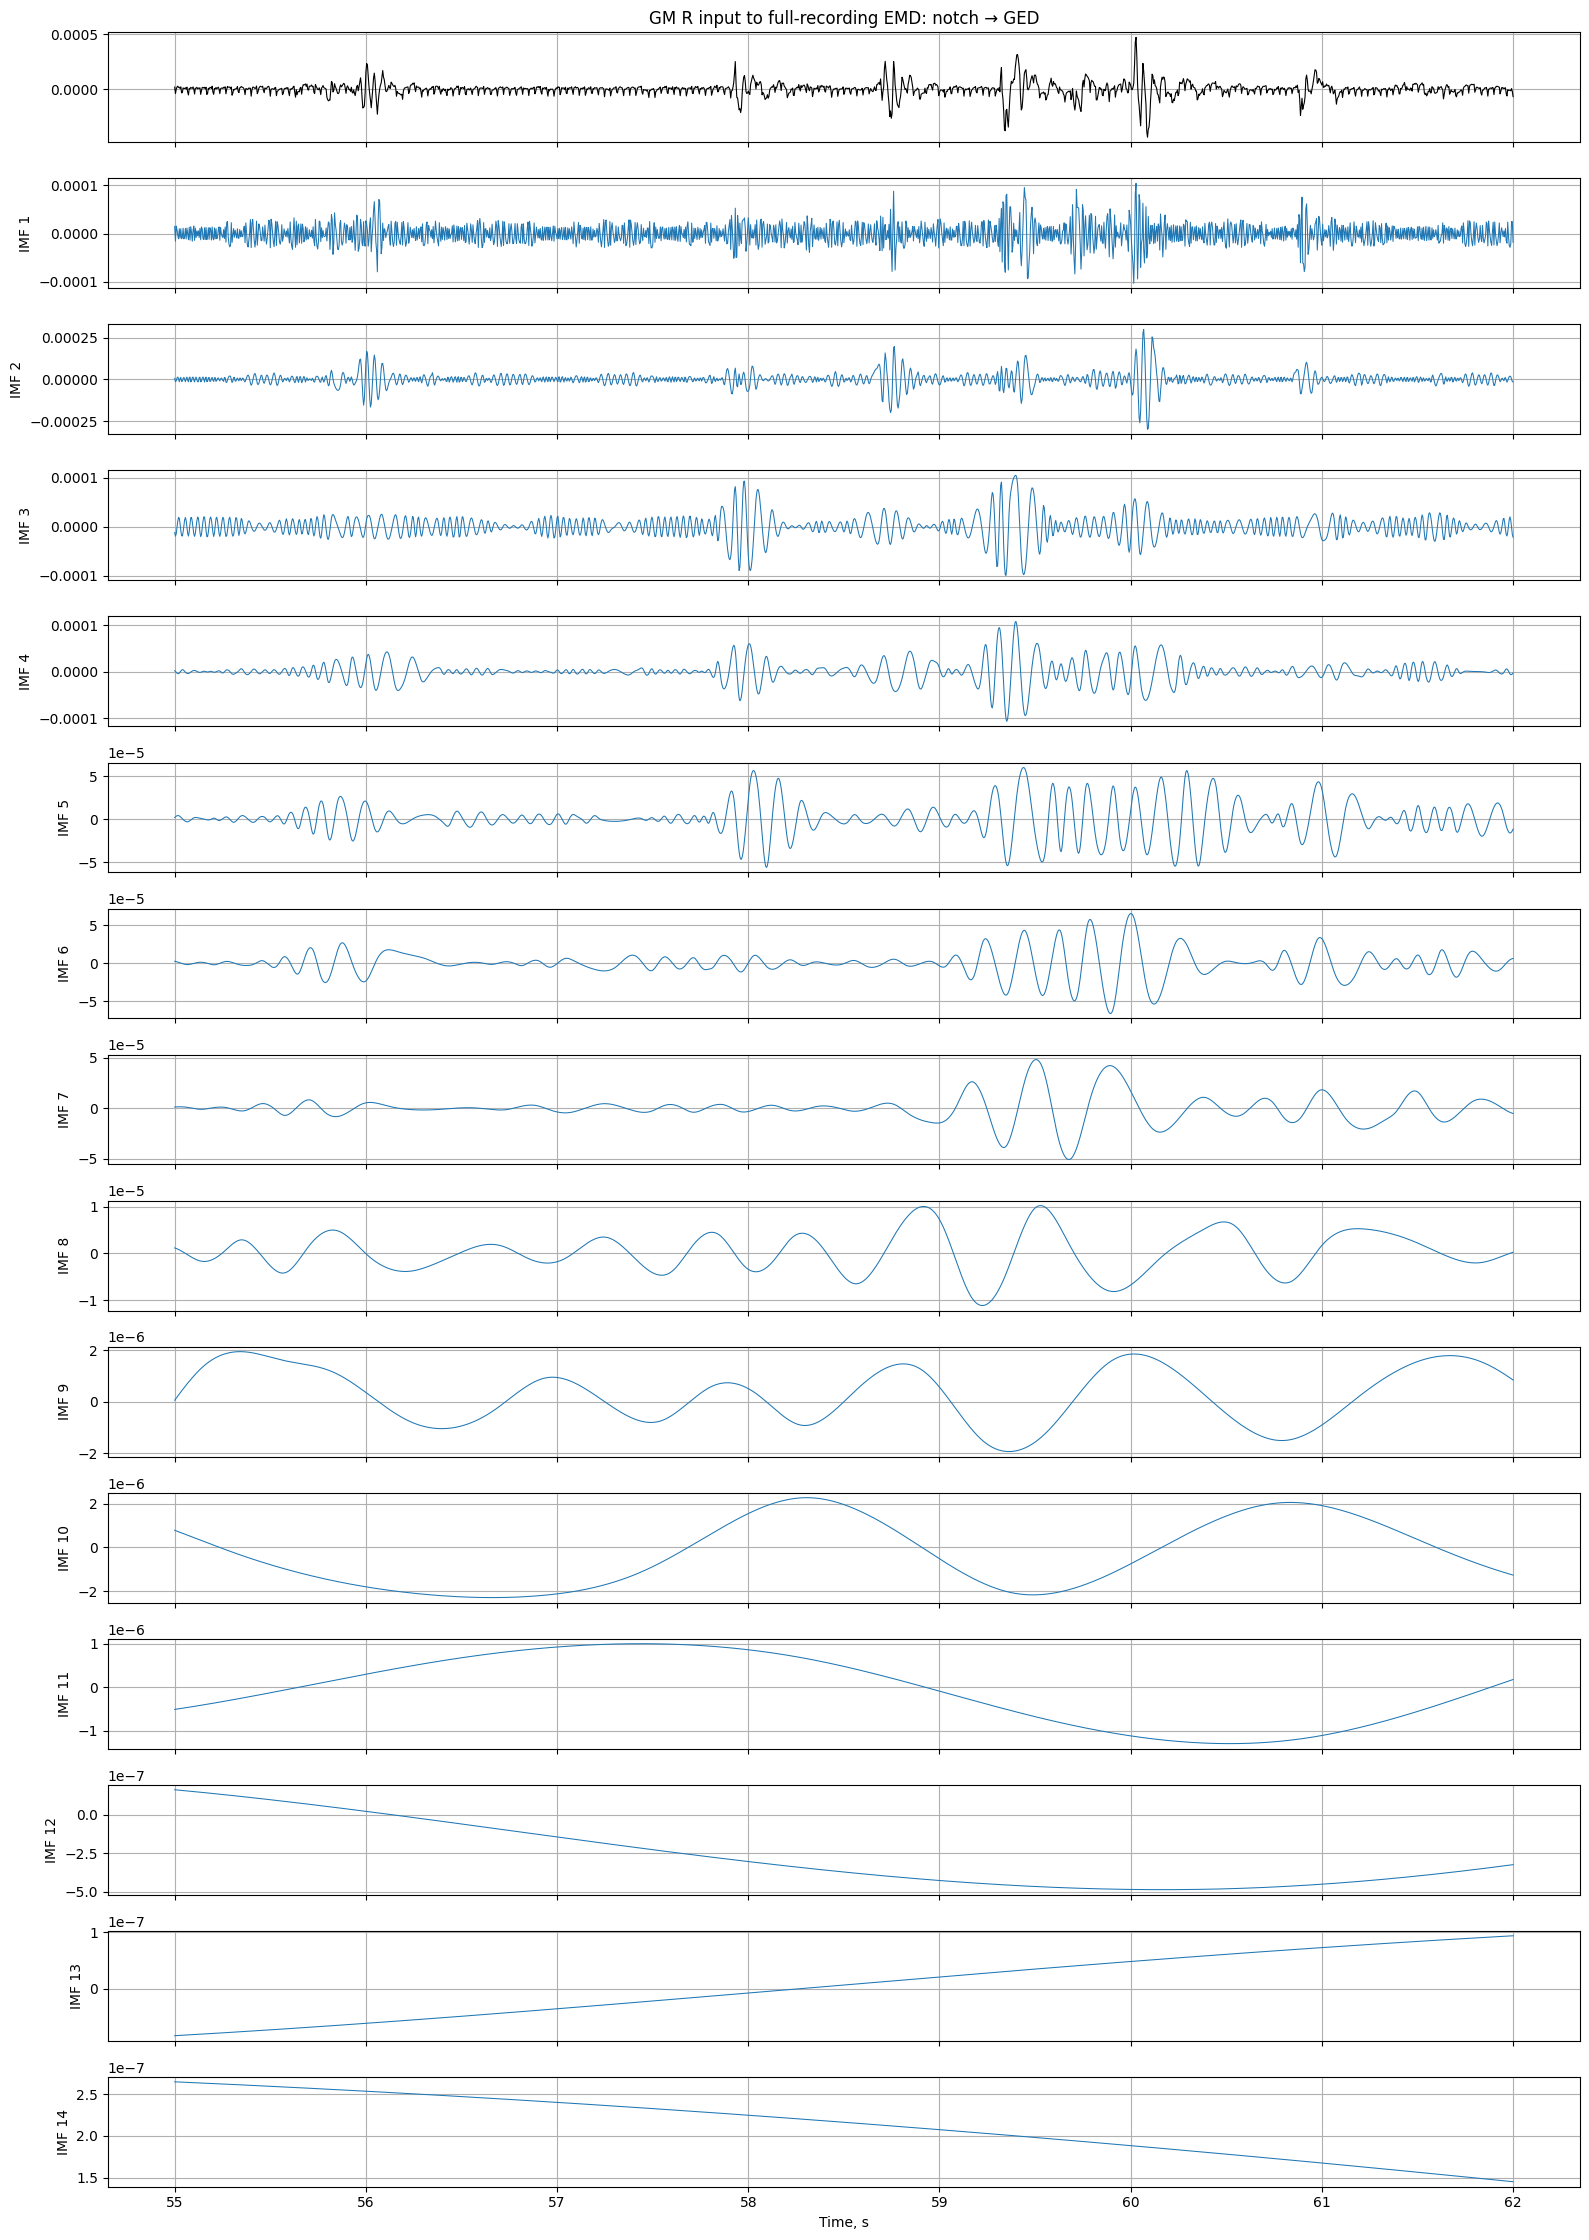

,channel,component,imf,"median frequency, Hz","rms in window, V","peak in window, V",remove
0,GM R,IMF 1,1,27.0,0.000033,0.000235,False
1,GM R,IMF 2,2,16.5,0.000026,0.000113,False
2,GM R,IMF 3,3,7.5,0.000014,0.000057,False
3,GM R,IMF 4,4,3.5,0.000010,0.000027,True
4,GM R,IMF 5,5,2.0,0.000005,0.000010,False
5,GM R,IMF 6,6,1.5,0.000001,0.000002,False
6,GM L,IMF 1,1,38.5,0.000031,0.000132,False
7,GM L,IMF 2,2,19.5,0.000034,0.000136,False
8,GM L,IMF 3,3,7.5,0.000043,0.000188,False
9,GM L,IMF 4,4,4.5,0.000025,0.000059,True


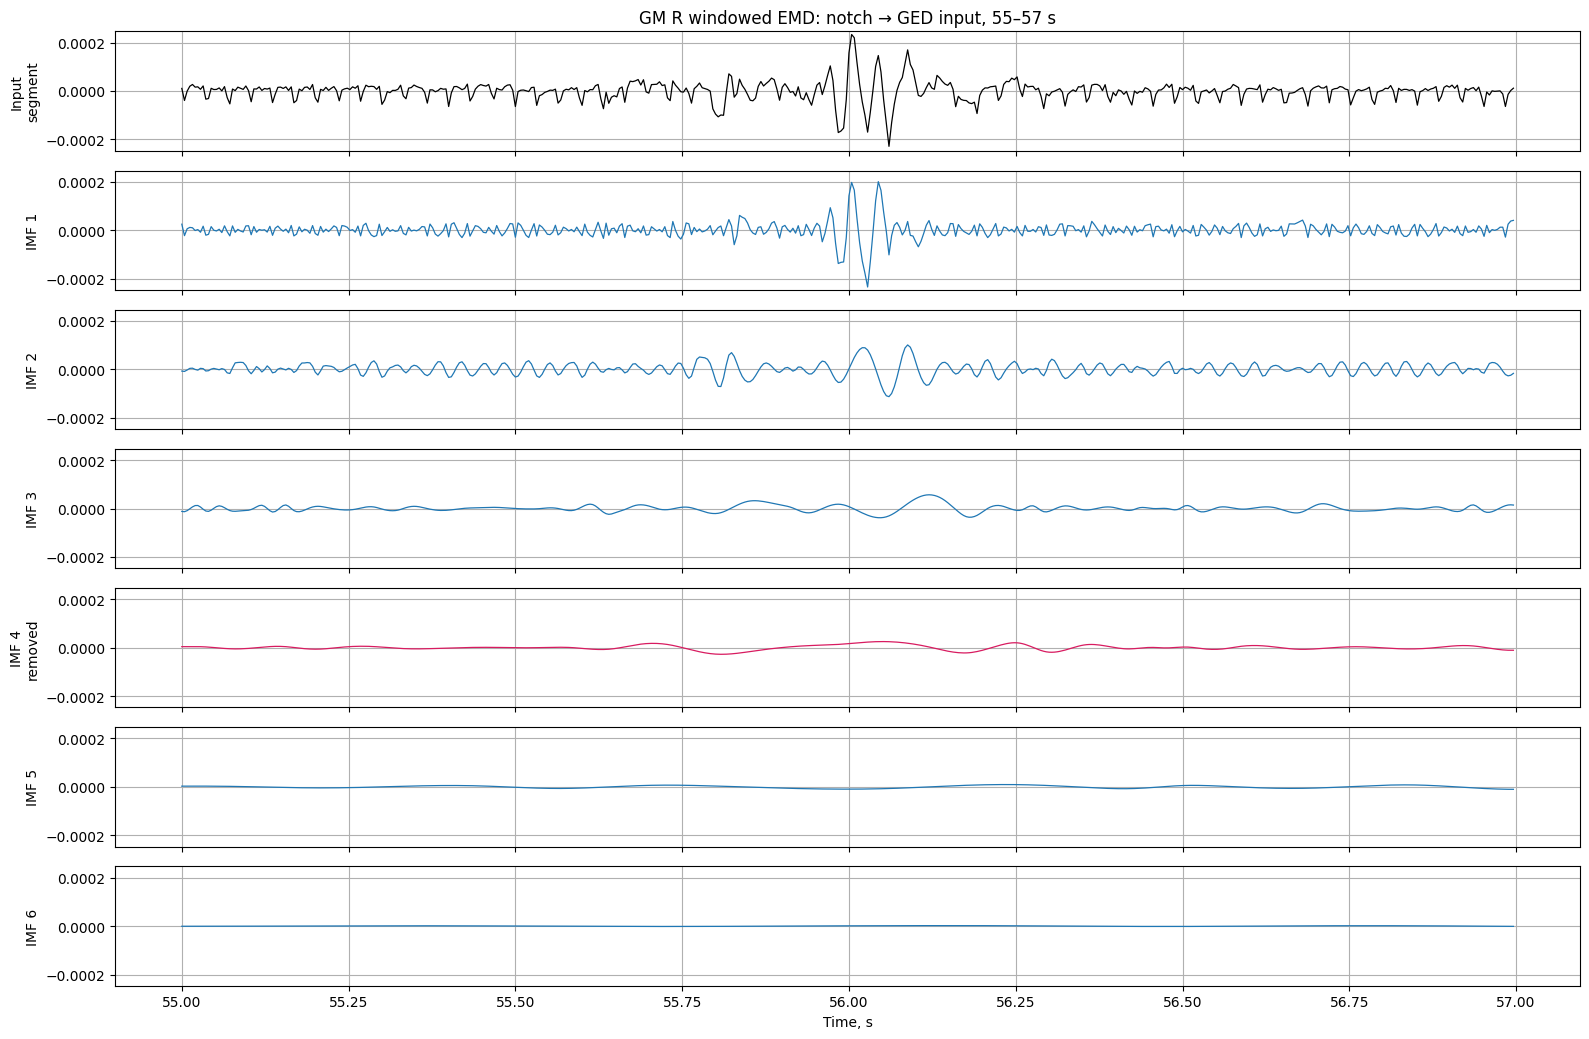

In [14]:
EMD_DEFAULT_REMOVE_IMFS = [4]
EMD_REMOVE_IMFS_BY_CHANNEL = {
    channel: list(EMD_DEFAULT_REMOVE_IMFS)
    for channel in analysis_channels
}
EMD_CHANNELS = list(analysis_channels)
EMD_TARGET_SFREQ = 250.0
EMD_ARTIFACT_RMS_RATIO_THRESHOLD = 2.0
EMD_REVIEW_CHANNEL = "GM R"
EMD_WINDOW_S = (55.0, 57.0)
EMD_WINDOW_REVIEW_CHANNEL = "GM R"
EMD_WINDOW_DEFAULT_REMOVE_IMFS = [4]
EMD_WINDOW_REMOVE_IMFS_BY_CHANNEL = {
    channel: list(EMD_WINDOW_DEFAULT_REMOVE_IMFS)
    for channel in analysis_channels
}

emd_factor = int(round(sfreq / EMD_TARGET_SFREQ))
if not np.isclose(sfreq / emd_factor, EMD_TARGET_SFREQ):
    raise ValueError(
        f"Sampling rate {sfreq} Hz cannot be reduced exactly "
        f"to {EMD_TARGET_SFREQ} Hz"
    )

print(
    f"EMD is fitted at {EMD_TARGET_SFREQ:g} Hz. "
    "Fast high-frequency artifact structure above the downsampled "
    "Nyquist frequency is not available to this EMD model."
)

def annotation_mask_at_sfreq(annotations, n_times, target_sfreq):
    mask = np.zeros(n_times, dtype=bool)
    for annotation in annotations:
        description = str(annotation["description"]).lower()
        if "artifact" not in description:
            continue
        onset = float(annotation["onset"])
        duration = float(annotation["duration"])
        start = max(0, int(np.floor(onset * target_sfreq)))
        stop = min(n_times, int(np.ceil((onset + duration) * target_sfreq)))
        if stop > start:
            mask[start:stop] = True
    return mask

def robust_center_scale(data, channel):
    center = float(np.median(data))
    scale = float(1.4826 * np.median(np.abs(data - center)))
    if not np.isfinite(scale) or scale <= np.finfo(float).eps:
        raise ValueError(f"{channel} has invalid robust scale for EMD")
    return center, scale

def imf_median_frequency(imf):
    frequencies, power = signal.welch(
        imf, fs=EMD_TARGET_SFREQ, nperseg=min(imf.size, 4096),
    )
    cumulative = np.cumsum(power)
    if cumulative[-1] <= np.finfo(float).eps:
        return 0.0
    return float(frequencies[
        np.searchsorted(cumulative, 0.5 * cumulative[-1])
    ])

def rms(data):
    if data.size == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(data))))

raw_ged_emd = raw_ged.copy().load_data()
emd_imfs_by_channel = {}
emd_residue_by_channel = {}
emd_artifact_model_by_channel = {}
emd_selected_imfs_by_channel = {}
emd_summary_rows = []
emd_specificity_rows = []
emd_model_n_times = signal.resample_poly(
    np.zeros(raw_ged.n_times), up=1, down=emd_factor,
).size
artifact_mask = annotation_mask_at_sfreq(
    raw_base.annotations, emd_model_n_times, EMD_TARGET_SFREQ,
)
clean_mask = ~artifact_mask
review_model_data = None

for channel in EMD_CHANNELS:
    channel_data = raw_ged.get_data(picks=[channel])[0]
    model_data = signal.resample_poly(channel_data, up=1, down=emd_factor)
    center, scale = robust_center_scale(model_data, channel)
    normalized = (model_data - center) / scale

    decomposition = EMD()
    decomposition.emd(normalized)
    normalized_imfs, normalized_residue = decomposition.get_imfs_and_residue()
    imfs = normalized_imfs * scale
    residue = normalized_residue * scale + center
    assert np.allclose(
        imfs.sum(axis=0) + residue,
        model_data,
        rtol=1e-8,
        atol=1e-12,
    )

    selected_imfs = [
        int(index) for index in EMD_REMOVE_IMFS_BY_CHANNEL[channel]
    ]
    if len(selected_imfs) != len(set(selected_imfs)):
        raise ValueError(
            f"EMD_REMOVE_IMFS_BY_CHANNEL[{channel!r}] contains duplicates"
        )
    invalid_imfs = [
        index for index in selected_imfs
        if index < 1 or index > len(imfs)
    ]
    if invalid_imfs:
        raise ValueError(
            f"Invalid IMF indices for {channel}: {invalid_imfs}; "
            f"available: 1..{len(imfs)}"
        )

    if model_data.size != artifact_mask.size:
        raise ValueError(
            f"Unexpected EMD model length for {channel}: "
            f"{model_data.size} != {artifact_mask.size}"
        )
    artifact_lowrate = np.zeros_like(model_data)
    for index in selected_imfs:
        artifact_lowrate += imfs[index - 1]

    artifact_model = signal.resample_poly(
        artifact_lowrate, up=emd_factor, down=1,
    )
    if artifact_model.size < raw_ged.n_times:
        artifact_model = np.pad(
            artifact_model,
            (0, raw_ged.n_times - artifact_model.size),
            mode="edge",
        )
    artifact_model = artifact_model[:raw_ged.n_times]

    channel_index = raw_ged_emd.ch_names.index(channel)
    raw_ged_emd._data[channel_index] = channel_data - artifact_model

    emd_imfs_by_channel[channel] = imfs
    emd_residue_by_channel[channel] = residue
    emd_artifact_model_by_channel[channel] = artifact_model
    emd_selected_imfs_by_channel[channel] = selected_imfs
    if channel == EMD_REVIEW_CHANNEL:
        review_model_data = model_data

    for index, imf in enumerate(imfs, start=1):
        artifact_rms = rms(imf[artifact_mask])
        clean_rms = rms(imf[clean_mask])
        artifact_peak = float(np.max(np.abs(imf[artifact_mask]))) if artifact_mask.any() else np.nan
        clean_peak = float(np.max(np.abs(imf[clean_mask]))) if clean_mask.any() else np.nan
        rms_ratio = artifact_rms / clean_rms if clean_rms > np.finfo(float).eps else np.nan
        peak_ratio = artifact_peak / clean_peak if clean_peak > np.finfo(float).eps else np.nan
        artifact_specific = bool(
            np.isfinite(rms_ratio)
            and rms_ratio >= EMD_ARTIFACT_RMS_RATIO_THRESHOLD
        )
        median_frequency = imf_median_frequency(imf)

        emd_summary_rows.append({
            "channel": channel,
            "component": f"IMF {index}",
            "imf": index,
            "median frequency, Hz": median_frequency,
            "remove": index in selected_imfs,
            "artifact-specific candidate": artifact_specific,
        })
        emd_specificity_rows.append({
            "channel": channel,
            "imf": index,
            "artifact rms, V": artifact_rms,
            "clean rms, V": clean_rms,
            "artifact/clean rms ratio": rms_ratio,
            "artifact peak, V": artifact_peak,
            "clean peak, V": clean_peak,
            "artifact/clean peak ratio": peak_ratio,
            "artifact-specific candidate": artifact_specific,
            "remove": index in selected_imfs,
        })

for channel in raw_ged.ch_names:
    if channel not in EMD_CHANNELS:
        assert np.array_equal(
            raw_ged_emd.get_data(picks=[channel]),
            raw_ged.get_data(picks=[channel]),
        )

emd_summary = pd.DataFrame(emd_summary_rows)
emd_artifact_specificity = pd.DataFrame(emd_specificity_rows)
display(emd_summary)
display(
    emd_artifact_specificity.sort_values(
        ["channel", "artifact/clean rms ratio"],
        ascending=[True, False],
    )
)

review_window_s = (55.0, 62.0)
if EMD_REVIEW_CHANNEL not in EMD_CHANNELS:
    raise ValueError(f"EMD_REVIEW_CHANNEL must be one of {EMD_CHANNELS}")
if review_model_data is None:
    raise ValueError(f"No EMD review data for {EMD_REVIEW_CHANNEL}")
review_imfs = emd_imfs_by_channel[EMD_REVIEW_CHANNEL]
emd_time = np.arange(review_model_data.size) / EMD_TARGET_SFREQ
review_mask = (
    (emd_time >= review_window_s[0])
    & (emd_time <= review_window_s[1])
)
fig, axes = plt.subplots(
    len(review_imfs) + 1, 1,
    figsize=(16, 1.5 * (len(review_imfs) + 1)),
    sharex=True,
)
axes[0].plot(
    emd_time[review_mask], review_model_data[review_mask],
    color="black", linewidth=0.8,
)
axes[0].set_title(f"{EMD_REVIEW_CHANNEL} input to full-recording EMD: notch → GED")
for index, (axis, imf) in enumerate(zip(axes[1:], review_imfs), start=1):
    axis.plot(emd_time[review_mask], imf[review_mask], linewidth=0.75)
    axis.set_ylabel(f"IMF {index}")
axes[-1].set_xlabel("Time, s")
fig.tight_layout()
plt.show()

raw_ged_emd.plot(
    **{**emg_browser_kwargs, "duration": 7.0},
    title=f"Notch → GED → full-recording EMD; removed IMF(s) {EMD_DEFAULT_REMOVE_IMFS}",
)

raw_ged_emd_windowed = raw_ged.copy().load_data()
emd_window_imfs_by_channel = {}
emd_window_residue_by_channel = {}
emd_window_artifact_model_by_channel = {}
emd_window_selected_imfs_by_channel = {}
emd_window_summary_rows = []
emd_window_review_model_data = None

window_raw_start = max(0, int(np.floor(EMD_WINDOW_S[0] * sfreq)))
window_raw_stop = min(raw_ged.n_times, int(np.ceil(EMD_WINDOW_S[1] * sfreq)))
if window_raw_stop <= window_raw_start:
    raise ValueError(f"Empty EMD window: {EMD_WINDOW_S}")
window_time = raw_ged.times[window_raw_start:window_raw_stop]

for channel in EMD_CHANNELS:
    channel_data = raw_ged.get_data(picks=[channel])[0]
    window_data = channel_data[window_raw_start:window_raw_stop]
    model_data = signal.resample_poly(window_data, up=1, down=emd_factor)
    center, scale = robust_center_scale(model_data, channel)
    normalized = (model_data - center) / scale

    decomposition = EMD()
    decomposition.emd(normalized)
    normalized_imfs, normalized_residue = decomposition.get_imfs_and_residue()
    imfs = normalized_imfs * scale
    residue = normalized_residue * scale + center
    assert np.allclose(
        imfs.sum(axis=0) + residue,
        model_data,
        rtol=1e-8,
        atol=1e-12,
    )

    selected_imfs = [
        int(index) for index in EMD_WINDOW_REMOVE_IMFS_BY_CHANNEL[channel]
    ]
    if len(selected_imfs) != len(set(selected_imfs)):
        raise ValueError(
            f"EMD_WINDOW_REMOVE_IMFS_BY_CHANNEL[{channel!r}] contains duplicates"
        )
    invalid_imfs = [
        index for index in selected_imfs
        if index < 1 or index > len(imfs)
    ]
    if invalid_imfs:
        raise ValueError(
            f"Invalid windowed IMF indices for {channel}: {invalid_imfs}; "
            f"available: 1..{len(imfs)}"
        )

    artifact_lowrate = np.zeros_like(model_data)
    for index in selected_imfs:
        artifact_lowrate += imfs[index - 1]
    artifact_window = signal.resample_poly(artifact_lowrate, up=emd_factor, down=1)
    if artifact_window.size < window_data.size:
        artifact_window = np.pad(
            artifact_window,
            (0, window_data.size - artifact_window.size),
            mode="edge",
        )
    artifact_window = artifact_window[:window_data.size]

    artifact_model = np.zeros(raw_ged.n_times)
    artifact_model[window_raw_start:window_raw_stop] = artifact_window
    channel_index = raw_ged_emd_windowed.ch_names.index(channel)
    raw_ged_emd_windowed._data[channel_index, window_raw_start:window_raw_stop] = (
        window_data - artifact_window
    )

    emd_window_imfs_by_channel[channel] = imfs
    emd_window_residue_by_channel[channel] = residue
    emd_window_artifact_model_by_channel[channel] = artifact_model
    emd_window_selected_imfs_by_channel[channel] = selected_imfs
    if channel == EMD_WINDOW_REVIEW_CHANNEL:
        emd_window_review_model_data = model_data

    for index, imf in enumerate(imfs, start=1):
        emd_window_summary_rows.append({
            "channel": channel,
            "component": f"IMF {index}",
            "imf": index,
            "median frequency, Hz": imf_median_frequency(imf),
            "rms in window, V": rms(imf),
            "peak in window, V": float(np.max(np.abs(imf))),
            "remove": index in selected_imfs,
        })

for channel in raw_ged.ch_names:
    before = raw_ged.get_data(picks=[channel])[0]
    after = raw_ged_emd_windowed.get_data(picks=[channel])[0]
    if channel in EMD_CHANNELS:
        assert np.array_equal(before[:window_raw_start], after[:window_raw_start])
        assert np.array_equal(before[window_raw_stop:], after[window_raw_stop:])
    else:
        assert np.array_equal(before, after)

emd_window_summary = pd.DataFrame(emd_window_summary_rows)
display(emd_window_summary)

if EMD_WINDOW_REVIEW_CHANNEL not in EMD_CHANNELS:
    raise ValueError(f"EMD_WINDOW_REVIEW_CHANNEL must be one of {EMD_CHANNELS}")
if emd_window_review_model_data is None:
    raise ValueError(f"No windowed EMD review data for {EMD_WINDOW_REVIEW_CHANNEL}")
window_review_imfs = emd_window_imfs_by_channel[EMD_WINDOW_REVIEW_CHANNEL]
window_model_time = (
    EMD_WINDOW_S[0] + np.arange(emd_window_review_model_data.size) / EMD_TARGET_SFREQ
)
selected_window_imfs = set(
    emd_window_selected_imfs_by_channel[EMD_WINDOW_REVIEW_CHANNEL]
)
plot_series = [emd_window_review_model_data, *window_review_imfs]
plot_limit = 1.05 * max(
    np.max(np.abs(series)) for series in plot_series if series.size
)
plot_limit = max(plot_limit, np.finfo(float).eps)
fig, axes = plt.subplots(
    len(window_review_imfs) + 1, 1,
    figsize=(16, 1.5 * (len(window_review_imfs) + 1)),
    sharex=True,
)
axes[0].plot(window_model_time, emd_window_review_model_data, color="black", linewidth=0.9)
axes[0].set_ylabel("Input\nsegment")
axes[0].set_title(
    f"{EMD_WINDOW_REVIEW_CHANNEL} windowed EMD: notch → GED input, "
    f"{EMD_WINDOW_S[0]:g}–{EMD_WINDOW_S[1]:g} s"
)
for index, (axis, imf) in enumerate(zip(axes[1:], window_review_imfs), start=1):
    is_removed = index in selected_window_imfs
    color = "#D81B60" if is_removed else "#1F77B4"
    label = f"IMF {index}" + ("\nremoved" if is_removed else "")
    axis.plot(window_model_time, imf, color=color, linewidth=0.9)
    axis.set_ylabel(label)
for axis in axes:
    axis.set_ylim(-plot_limit, plot_limit)
axes[-1].set_xlabel("Time, s")
fig.tight_layout()
plt.show()

raw_ged_emd_windowed.plot(
    **{**emg_browser_kwargs, "duration": 7.0, "start": EMD_WINDOW_S[0]},
    title=(
        f"Notch → GED → windowed EMD; removed IMF(s) "
        f"{EMD_WINDOW_DEFAULT_REMOVE_IMFS}, {EMD_WINDOW_S[0]:g}–{EMD_WINDOW_S[1]:g} s"
    ),
)

## Сравнение методов с исходной записью

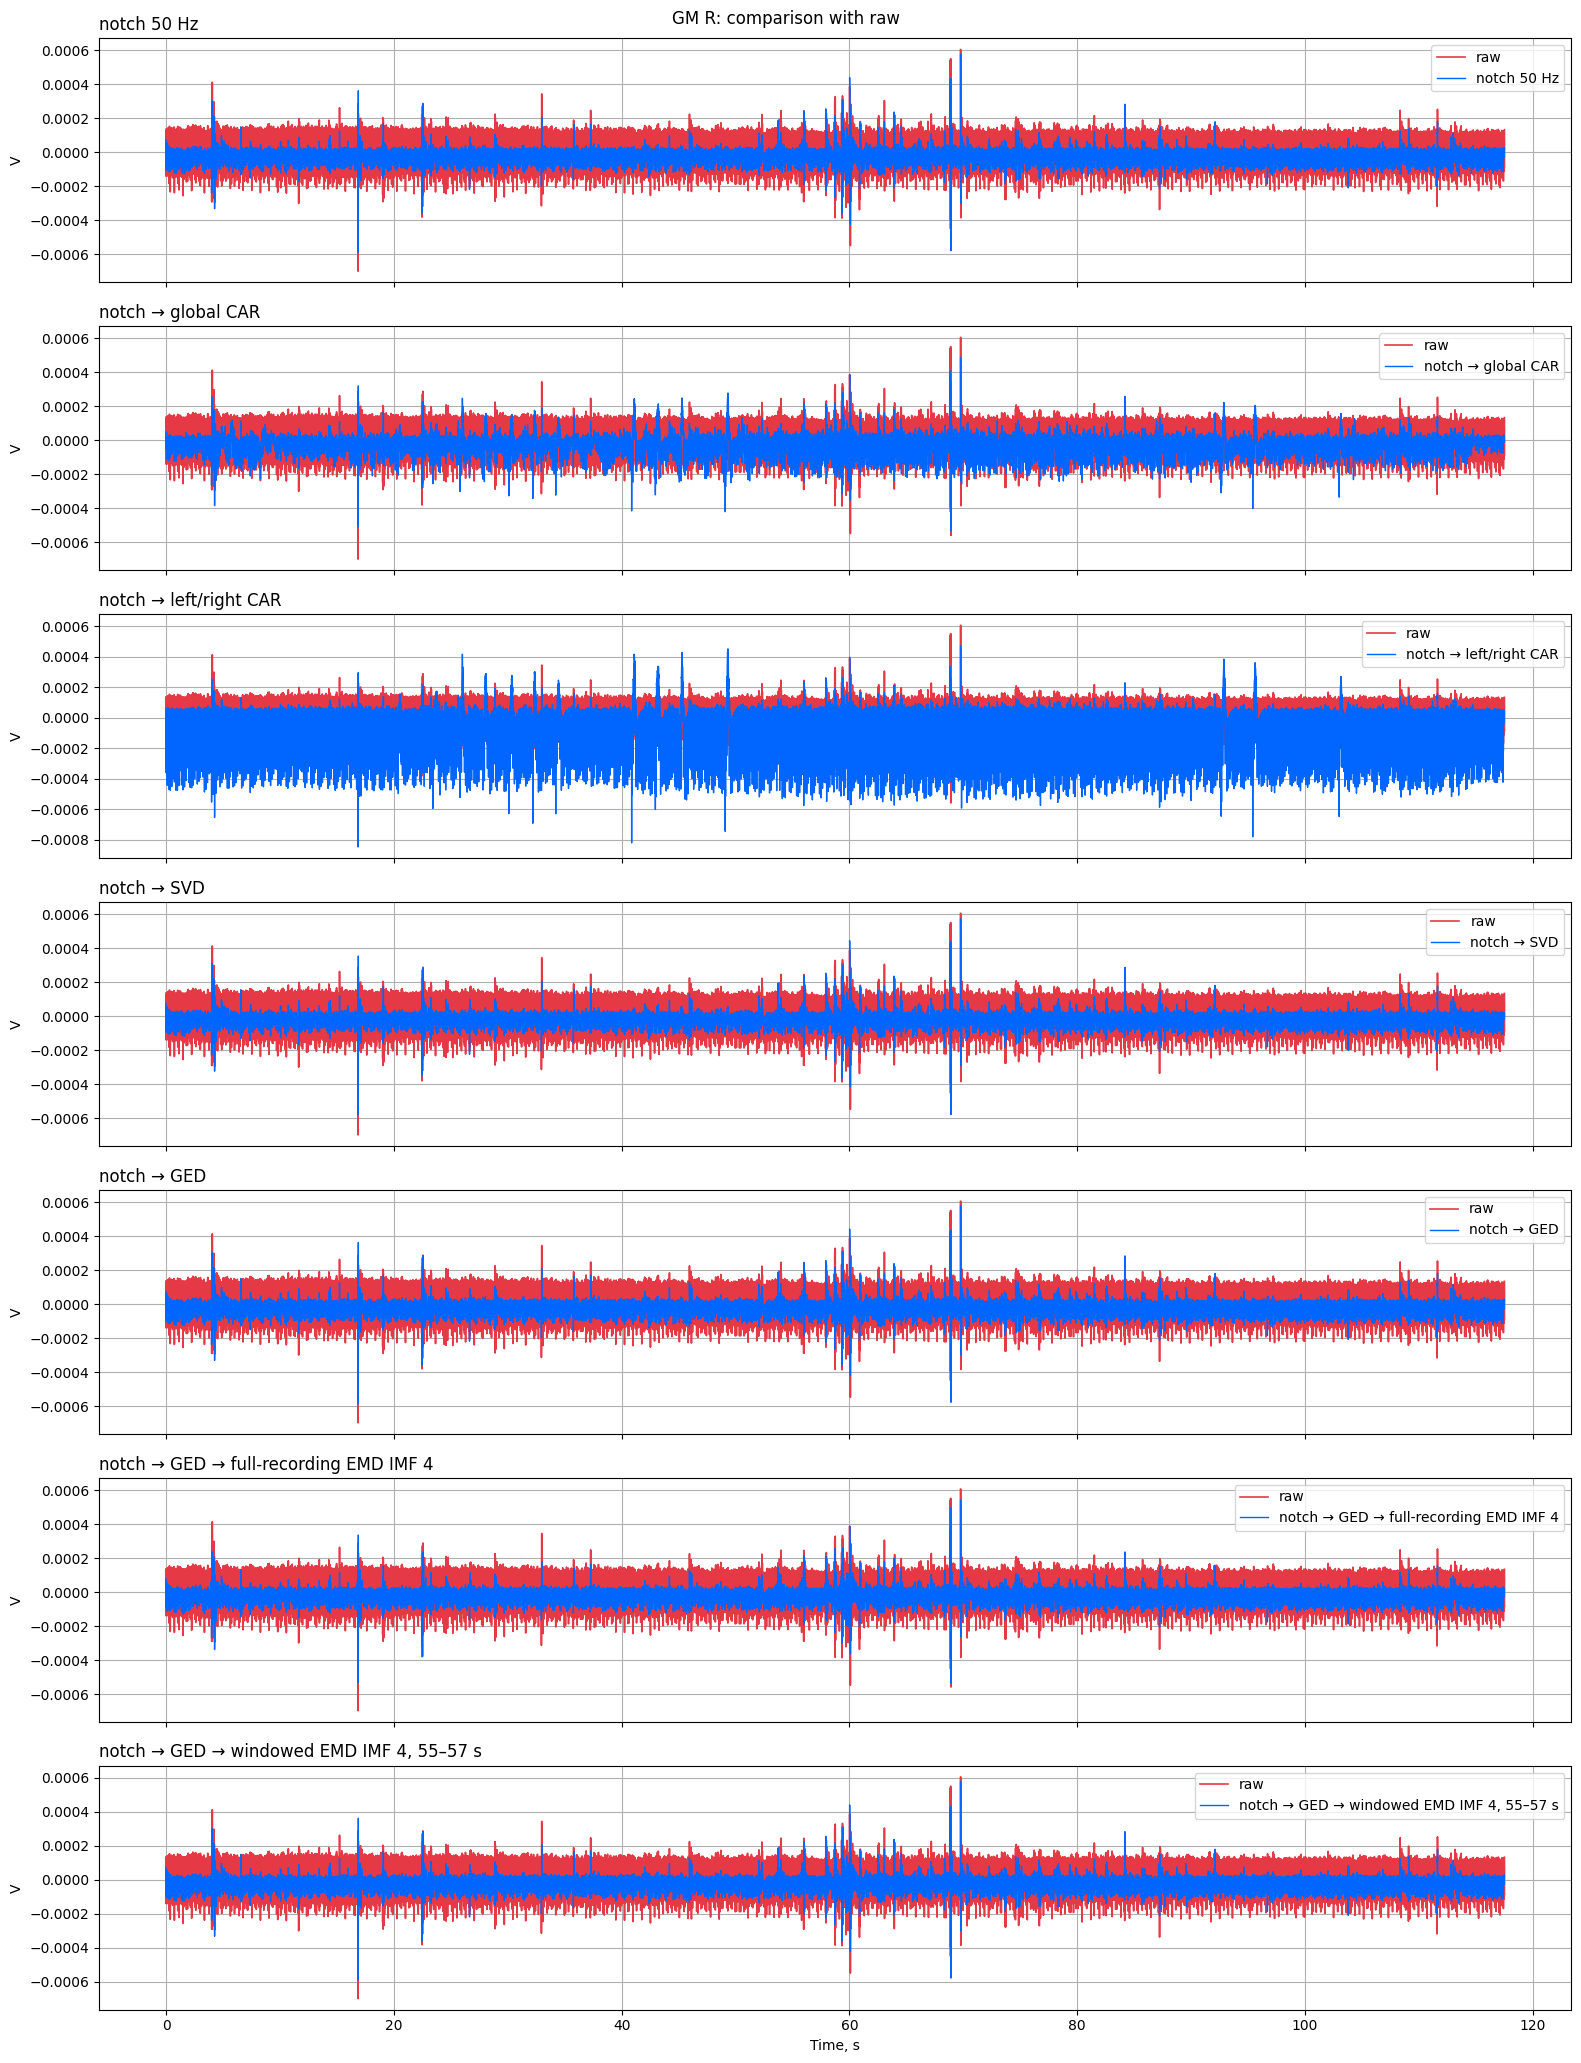

In [15]:
records = {
    "raw": raw_base,
    "notch 50 Hz": raw_notch,
    "notch → global CAR": raw_car_global,
    "notch → left/right CAR": raw_car_left_right,
    "notch → SVD": raw_svd,
    "notch → GED": raw_ged,
    "notch → GED → full-recording EMD IMF 4": raw_ged_emd,
    "notch → GED → windowed EMD IMF 4, 55–57 s": raw_ged_emd_windowed,
}

PLOT_CHANNEL = "GM R"
max_plot_points = 20_000
plot_step = max(1, raw_base.n_times // max_plot_points)
plot_time = raw_base.times[::plot_step]
raw_view = raw_base.get_data(picks=[PLOT_CHANNEL])[0, ::plot_step]
method_records = {
    name: record for name, record in records.items()
    if name != "raw"
}
fig, axes = plt.subplots(
    len(method_records), 1,
    figsize=(16, 3 * len(method_records)),
    sharex=True,
)
for axis, (name, record) in zip(axes, method_records.items()):
    method_view = record.get_data(
        picks=[PLOT_CHANNEL]
    )[0, ::plot_step]
    axis.plot(plot_time, raw_view, color="#E63946", lw=1.2, label="raw")
    axis.plot(plot_time, method_view, color="#0066FF", lw=1.0, label=name)
    axis.set_title(name, loc="left")
    axis.set_ylabel("V")
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Time, s")
fig.suptitle(f"{PLOT_CHANNEL}: comparison with raw")
fig.tight_layout()
plt.show()

## Межканальные корреляции

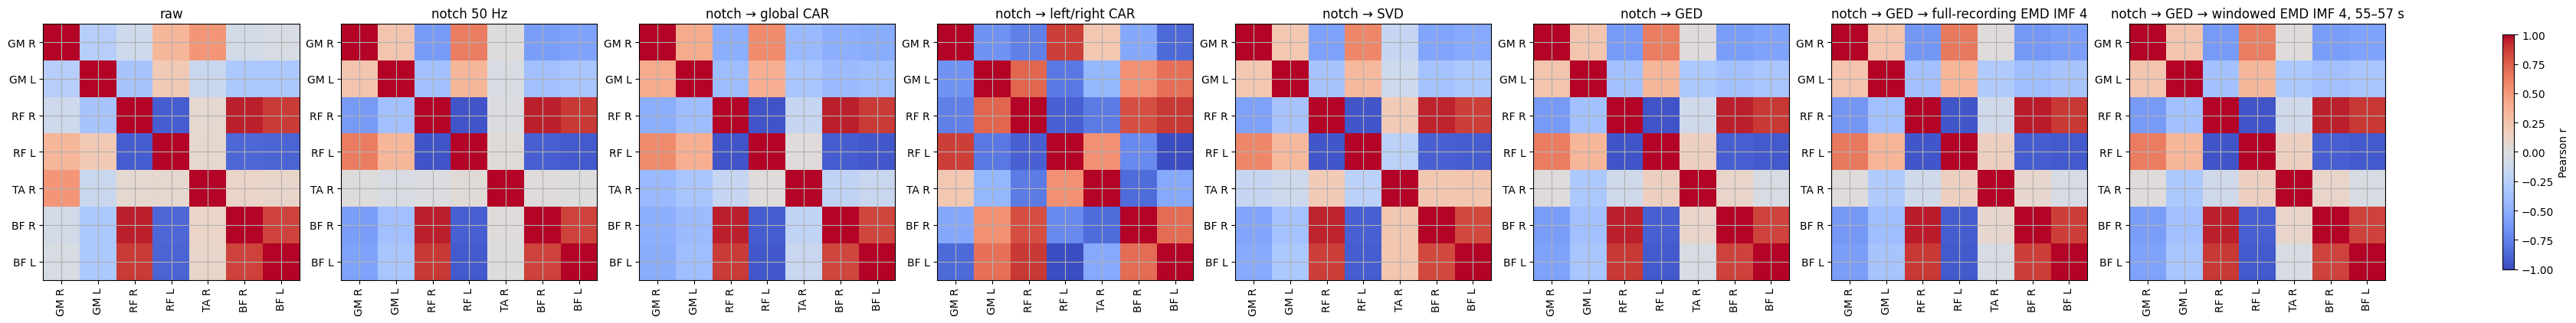

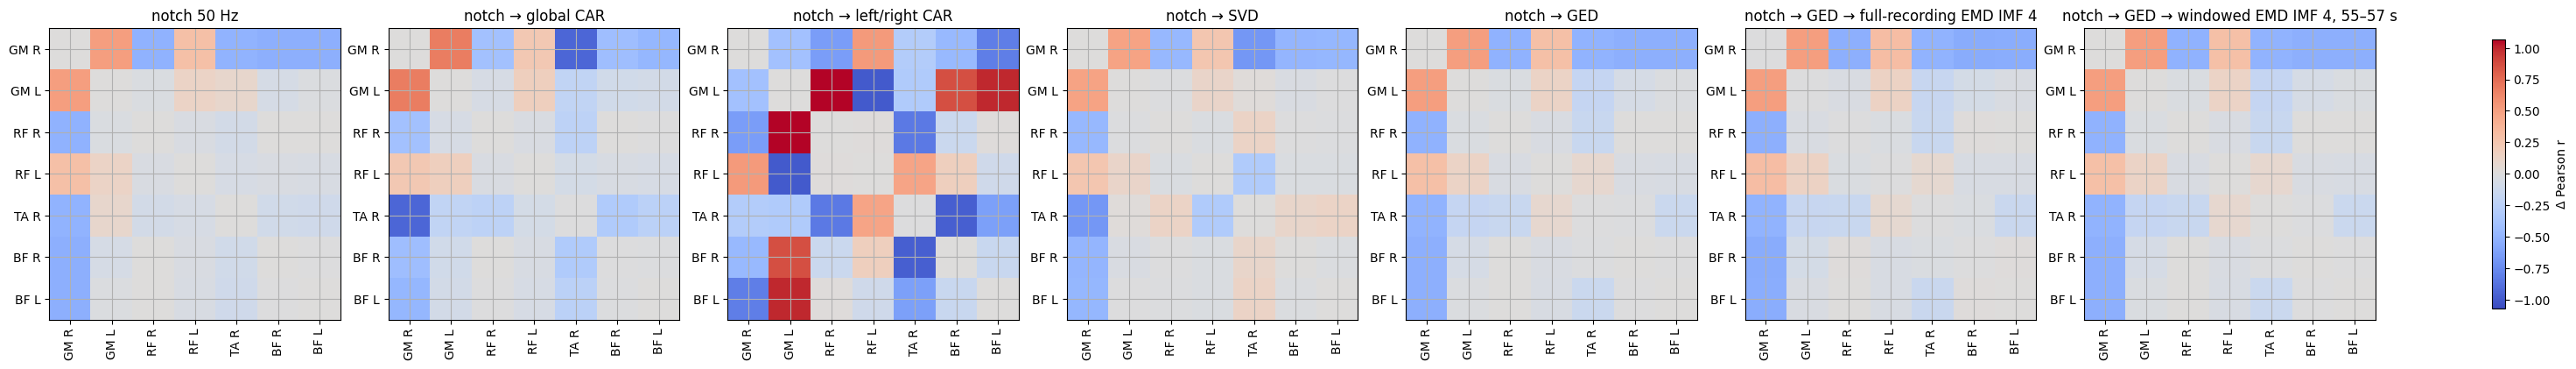

In [16]:
correlation_matrices = {
    name: np.corrcoef(record.get_data(picks=analysis_channels))
    for name, record in records.items()
}
fig, axes = plt.subplots(
    1, len(correlation_matrices),
    figsize=(4.2 * len(correlation_matrices), 4.3),
    constrained_layout=True,
)
for axis, (name, matrix) in zip(axes, correlation_matrices.items()):
    image = axis.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_title(name)
    axis.set_xticks(range(len(analysis_channels)), analysis_channels, rotation=90)
    axis.set_yticks(range(len(analysis_channels)), analysis_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label="Pearson r")
plt.show()

raw_correlation = correlation_matrices["raw"]
method_correlations = {
    name: matrix for name, matrix in correlation_matrices.items()
    if name != "raw"
}
delta_limit = max(
    np.max(np.abs(matrix - raw_correlation))
    for matrix in method_correlations.values()
)
fig, axes = plt.subplots(
    1, len(method_correlations),
    figsize=(4.2 * len(method_correlations), 4.3),
    constrained_layout=True,
)
for axis, (name, matrix) in zip(axes, method_correlations.items()):
    image = axis.imshow(
        matrix - raw_correlation,
        cmap="coolwarm",
        vmin=-delta_limit,
        vmax=delta_limit,
    )
    axis.set_title(name)
    axis.set_xticks(range(len(analysis_channels)), analysis_channels, rotation=90)
    axis.set_yticks(range(len(analysis_channels)), analysis_channels)
fig.colorbar(image, ax=axes, shrink=0.75, label="Δ Pearson r")
plt.show()


## Сохранение результатов

In [17]:
emd_output_path = data_processed_dir / "recording_notch_ged_emd_imf4_raw.fif"
emd_windowed_output_path = data_processed_dir / "recording_notch_ged_emd_window_55_57s_imf4_raw.fif"
output_paths = {
    "notch 50 Hz": data_interim_dir / "recording_notch_50hz_raw.fif",
    "notch → global CAR": data_interim_dir / "recording_notch_car_global_raw.fif",
    "notch → left/right CAR": data_interim_dir / "recording_notch_car_left_right_raw.fif",
    "notch → SVD": data_interim_dir / "recording_notch_svd_k1_slow_raw.fif",
    "notch → GED": data_interim_dir / "recording_notch_ged_slow_raw.fif",
    "notch → GED → full-recording EMD IMF 4": emd_output_path,
    "notch → GED → windowed EMD IMF 4, 55–57 s": emd_windowed_output_path,
}
output_records = {
    "notch 50 Hz": raw_notch,
    "notch → global CAR": raw_car_global,
    "notch → left/right CAR": raw_car_left_right,
    "notch → SVD": raw_svd,
    "notch → GED": raw_ged,
    "notch → GED → full-recording EMD IMF 4": raw_ged_emd,
    "notch → GED → windowed EMD IMF 4, 55–57 s": raw_ged_emd_windowed,
}
for name, record in output_records.items():
    record.save(output_paths[name], overwrite=True)
    print(f"{name}: {output_paths[name]}")

np.savez(
    qc_dir / "notch_50hz_filter.npz",
    channels=np.asarray(analysis_channels),
    line_freq_hz=LINE_FREQ_HZ,
    line_notch_q=LINE_NOTCH_Q,
    numerator=notch_b,
    denominator=notch_a,
)
np.savez(
    qc_dir / "notch_svd_k1_slow_model.npz",
    channels=np.asarray(analysis_channels),
    covariance=svd_covariance,
    singular_values=svd_singular_values,
    artifact_direction=artifact_direction,
    projector=svd_projector,
    artifact_cutoff_hz=ARTIFACT_CUTOFF_HZ,
)
np.savez(
    qc_dir / "notch_ged_slow_model.npz",
    channels=np.asarray(analysis_channels),
    covariance_artifact=artifact_covariance,
    covariance_normal=normal_covariance,
    eigenvalues=power_ratios,
    ged_filters=ged_filters,
    spatial_patterns=spatial_patterns,
    artifact_cutoff_hz=ARTIFACT_CUTOFF_HZ,
)

emd_model_archive = {
    "channels": np.asarray(EMD_CHANNELS),
    "default_remove_imfs": np.asarray(EMD_DEFAULT_REMOVE_IMFS, dtype=int),
    "model_sfreq": EMD_TARGET_SFREQ,
    "original_sfreq": sfreq,
    "artifact_rms_ratio_threshold": EMD_ARTIFACT_RMS_RATIO_THRESHOLD,
}
for channel in EMD_CHANNELS:
    key = channel.replace(" ", "_").replace("-", "_")
    emd_model_archive[f"{key}_remove_imfs"] = np.asarray(
        emd_selected_imfs_by_channel[channel], dtype=int,
    )
    emd_model_archive[f"{key}_imfs"] = emd_imfs_by_channel[channel]
    emd_model_archive[f"{key}_residue"] = emd_residue_by_channel[channel]
    emd_model_archive[f"{key}_artifact_model"] = emd_artifact_model_by_channel[channel]
np.savez_compressed(
    qc_dir / "notch_ged_emd_imf4_model.npz",
    **emd_model_archive,
)

emd_window_model_archive = {
    "channels": np.asarray(EMD_CHANNELS),
    "default_remove_imfs": np.asarray(EMD_WINDOW_DEFAULT_REMOVE_IMFS, dtype=int),
    "fit_window_s": np.asarray(EMD_WINDOW_S, dtype=float),
    "model_sfreq": EMD_TARGET_SFREQ,
    "original_sfreq": sfreq,
}
for channel in EMD_CHANNELS:
    key = channel.replace(" ", "_").replace("-", "_")
    emd_window_model_archive[f"{key}_remove_imfs"] = np.asarray(
        emd_window_selected_imfs_by_channel[channel], dtype=int,
    )
    emd_window_model_archive[f"{key}_imfs"] = emd_window_imfs_by_channel[channel]
    emd_window_model_archive[f"{key}_residue"] = emd_window_residue_by_channel[channel]
    emd_window_model_archive[f"{key}_artifact_model"] = emd_window_artifact_model_by_channel[channel]
np.savez_compressed(
    qc_dir / "notch_ged_emd_window_55_57s_imf4_model.npz",
    **emd_window_model_archive,
)
emd_summary.to_csv(
    tables_dir / "notch_ged_emd_imf_summary.csv",
    index=False,
)
emd_artifact_specificity.to_csv(
    tables_dir / "notch_ged_emd_artifact_specificity.csv",
    index=False,
)
emd_window_summary.to_csv(
    tables_dir / "notch_ged_emd_window_55_57s_imf_summary.csv",
    index=False,
)

reloaded_emd = mne.io.read_raw_fif(emd_output_path, preload=True)
assert reloaded_emd.ch_names == raw_ged_emd.ch_names
assert reloaded_emd.info["sfreq"] == raw_ged_emd.info["sfreq"]
assert reloaded_emd.n_times == raw_ged_emd.n_times
assert np.allclose(reloaded_emd.get_data(), raw_ged_emd.get_data())
reloaded_emd_windowed = mne.io.read_raw_fif(emd_windowed_output_path, preload=True)
assert reloaded_emd_windowed.ch_names == raw_ged_emd_windowed.ch_names
assert reloaded_emd_windowed.info["sfreq"] == raw_ged_emd_windowed.info["sfreq"]
assert reloaded_emd_windowed.n_times == raw_ged_emd_windowed.n_times
assert np.allclose(
    reloaded_emd_windowed.get_data(),
    raw_ged_emd_windowed.get_data(),
)

changed_summary = []
for channel in EMD_CHANNELS:
    before = raw_ged.get_data(picks=[channel])[0]
    after = raw_ged_emd.get_data(picks=[channel])[0]
    difference = before - after
    changed_summary.append({
        "channel": channel,
        "removed rms, V": rms(difference),
        "removed peak, V": float(np.max(np.abs(difference))),
        "before/after correlation": float(np.corrcoef(before, after)[0, 1]),
    })
display(pd.DataFrame(changed_summary))

windowed_changed_summary = []
for channel in EMD_CHANNELS:
    before = raw_ged.get_data(picks=[channel])[0]
    after = raw_ged_emd_windowed.get_data(picks=[channel])[0]
    difference = before - after
    windowed_changed_summary.append({
        "channel": channel,
        "removed rms in window, V": rms(difference[window_raw_start:window_raw_stop]),
        "removed peak in window, V": float(
            np.max(np.abs(difference[window_raw_start:window_raw_stop]))
        ),
        "outside-window unchanged": bool(
            np.array_equal(before[:window_raw_start], after[:window_raw_start])
            and np.array_equal(before[window_raw_stop:], after[window_raw_stop:])
        ),
    })
display(pd.DataFrame(windowed_changed_summary))
print("Saved full-recording EMD output verified:", emd_output_path)
print("Saved windowed EMD output verified:", emd_windowed_output_path)

notch 50 Hz: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_50hz_raw.fif
notch → global CAR: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_car_global_raw.fif
notch → left/right CAR: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_car_left_right_raw.fif
notch → SVD: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_svd_k1_slow_raw.fif
notch → GED: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/interim/recording_notch_ged_slow_raw.fif
notch → GED → full-recording EMD IMF 4: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed/recording_notch_ged_emd_imf4_raw.fif
notch → GED → windowed EMD IMF 4, 55–57 s: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed/recording_notch_ged_emd_window_55_57s_imf4_raw.fif


,channel,"removed rms, V","removed peak, V",before/after correlation
0,GM R,0.000010,0.000109,0.966929
1,GM L,0.000027,0.000392,0.935308
2,RF R,0.000018,0.000095,0.997034
3,RF L,0.000051,0.000216,0.995663
4,TA R,0.000003,0.000027,0.989838
5,BF R,0.000023,0.000275,0.989258
6,BF L,0.000038,0.000286,0.990668


,channel,"removed rms in window, V","removed peak in window, V",outside-window unchanged
0,GM R,0.000010,0.000027,True
1,GM L,0.000025,0.000059,True
2,RF R,0.000023,0.000083,True
3,RF L,0.000048,0.000162,True
4,TA R,0.000004,0.000012,True
5,BF R,0.000015,0.000042,True
6,BF L,0.000032,0.000083,True


Saved full-recording EMD output verified: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed/recording_notch_ged_emd_imf4_raw.fif
Saved windowed EMD output verified: /Users/sofiaefimochkina/Documents/emg_artifacts_filter/data/processed/recording_notch_ged_emd_window_55_57s_imf4_raw.fif
